In [1]:
from langchain_openai import OpenAIEmbeddings
from langchain_chroma import Chroma


embeddings = OpenAIEmbeddings(model="text-embedding-3-large")

vector_store = Chroma(
    collection_name="income_tax_collection",
    persist_directory="./income_tax_collection",
    embedding_function=embeddings
)

retriever = vector_store.as_retriever(search_kwargs={'k': 3})


In [2]:
from typing_extensions import List, TypedDict
from langchain_core.documents import Document
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    query: str
    context: List[Document]
    answer: str

graph_builder = StateGraph(AgentState)

In [3]:
def retrieve(state: AgentState):
    query = state['query']
    docs = retriever.invoke(query)
    return {"context": docs}

In [ ]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model='gpt-4o')

In [5]:
from langsmith import Client

client = Client()
generate_prompt = client.pull_prompt("rlm/rag-prompt")

def generate(state: AgentState):
    context = state['context']
    query = state['query']
    rag_chain = generate_prompt | llm
    response =rag_chain.invoke({'question': query, 'context': context})
    return {'answer': response}

In [6]:
from langsmith import Client
from typing import Literal

client = Client()
doc_relevance_prompt = client.pull_prompt("langchain-ai/rag-document-relevance")

def check_doc_relevance(state: AgentState) -> Literal['generate', 'rewrite']:
    query = state["query"]
    context = state["context"]
    print(f'context == {context}')
    doc_relevance_chain = doc_relevance_prompt | llm
    response = doc_relevance_chain.invoke({'question': query, 'documents': context})
    print(f'doc relevance response: {response}')
    if response['Score'] == 1:
        return 'generate'
    return 'rewrite'


In [7]:
query = '연봉 5천만원 직장인의 소득세는?'

In [ ]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

dictionary = ['사람과 관련된 표현 -> 거주자']

rewrite_prompt = PromptTemplate.from_template(f"""
사용자의 질문을 보고, 우리의 사전을 참고해서 사용자의 질문을 변경해주세요
사전: {dictionary}
질문: {{query}}
""")

def rewrite(state: AgentState):
    query = state['query']
    rewrite_chain = rewrite_prompt | llm | StrOutputParser()
    response = rewrite_chain.invoke({'query': query})
    return {'query': response}


In [9]:
graph_builder.add_node('retrieve', retrieve)
graph_builder.add_node('generate', generate)
graph_builder.add_node('rewrite', rewrite)

In [10]:
from langgraph.graph import START, END

graph_builder.add_edge(START, 'retrieve')
graph_builder.add_conditional_edges('retrieve', check_doc_relevance)
graph_builder.add_edge('rewrite', 'retrieve')
graph_builder.add_edge('generate', END)

In [11]:
graph = graph_builder.compile()



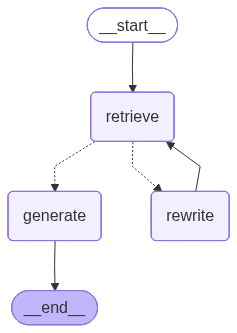

In [12]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [13]:
initial_state = {'query': '연봉 5천만원 세금'}
graph.invoke(initial_state)

context == [Document(id='9c0a0cd7-faa5-4a1e-b47a-86e79edf6101', metadata={'article': '제84조(기타소득의 과세최저한)'}, page_content='제84조(기타소득의 과세최저한) 기타소득이 다음 각 호의 어느 하나에 해당하면 그 소득에 대한 소득세를 과세하지 아니한다. <개정 2014. 12. 23., 2015. 12. 15., 2022. 12. 31.>\n1. 제21조제1항제4호에 따른 환급금으로서 건별로 승마투표권, 승자투표권, 소싸움경기투표권, 체육진흥투표권의 권면에 표시된 금액의 합계액이 10만원 이하이고 다음 각 목의 어느 하나에 해당하는 경우\n가. 적중한 개별투표당 환급금이 10만원 이하인 경우\n나. 단위투표금액당 환급금이 단위투표금액의 100배 이하이면서 적중한 개별투표당 환급금이 200만원 이하인 경우\n2. 제14조제3항제8호라목에 따른 복권 당첨금(복권당첨금을 복권 및 복권 기금법령에 따라 분할하여 지급받는 경우에는 분할하여 지급받는 금액의 합계액을 말한다) 또는 제21조제1항제14호에 따른 당첨금품등이 건별로 200만원 이하인 경우\n3. 그 밖의 기타소득금액(제21조제1항제21호의 기타소득금액은 제외한다)이 건별로 5만원 이하인 경우\n[전문개정 2009. 12. 31.]'), Document(id='df6208fe-f925-4b50-9903-8c57786d4242', metadata={'article': '제84조(기타소득의 과세최저한)'}, page_content='제84조(기타소득의 과세최저한) 기타소득이 다음 각 호의 어느 하나에 해당하면 그 소득에 대한 소득세를 과세하지 아니한다. <개정 2014. 12. 23., 2015. 12. 15., 2020. 12. 29., 2022. 12. 31.>\n1. 제21조제1항제4호에 따른 환급금으로서 건별로 승마투표권, 승자투표권, 소싸움경기투표권, 체육진흥투표권의 권면에 표시된 금액의 합계액이 10만원 이하이고 다음 

{'query': '거주자의 연봉 5천만원에 대한 세금은 얼마인가요?',
 'context': [Document(id='83502ad6-fd8e-4c74-8433-e1f11fcc5a2a', metadata={'article': '제55조(세율)'}, page_content='제55조(세율) ①거주자의 종합소득에 대한 소득세는 해당 연도의 종합소득과세표준에 다음의 세율을 적용하여 계산한 금액(이하 “종합소득산출세액”이라 한다)을 그 세액으로 한다. <개정 2014. 1. 1., 2016. 12. 20., 2017. 12. 19., 2020. 12. 29., 2022. 12. 31.>\n| 구분 | 종합소득 과세표준 구간 | 세율 |\n|------|----------------------|------|\n| 1 | 1,400만원 이하 | 과세표준의 6% |\n| 2 | 1,400만원 초과 ~ 5,000만원 이하 | 84만원 + [(1,400만원 초과 금액) × 15%] |\n| 3 | 5,000만원 초과 ~ 8,800만원 이하 | 624만원 + [(5,000만원 초과 금액) × 24%] |\n| 4 | 8,800만원 초과 ~ 1억5천만원 이하 | 1,536만원 + [(8,800만원 초과 금액) × 35%] |\n| 5 | 1억5천만원 초과 ~ 3억원 이하 | 3,706만원 + [(1억5천만원 초과 금액) × 38%] |\n| 6 | 3억원 초과 ~ 5억원 이하 | 9,406만원 + [(3억원 초과 금액) × 40%] |\n| 7 | 5억원 초과 ~ 10억원 이하 | 1억 7,406만원 + [(5억원 초과 금액) × 42%] |\n| 8 | 10억원 초과 | 3억 8,406만원 + [(10억원 초과 금액) × 45%] |\n② 거주자의 퇴직소득에 대한 소득세는 다음 각 호의 순서에 따라 계산한 금액(이하 “퇴직소득 산출세액”이라 한다)으로 한다.<개정 2013. 1. 1., 2014. 12. 23.>\n1. 해당 과세기간의 퇴직소득과세표준에 제1항의 세율을 적용하